In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

Reads the data from a given file.

In [3]:
def load_data(file_path):
    return np.loadtxt(file_path)

Returns the number of data.

In [4]:
def samples_countgth(data):
    rows, _ = data.shape
    return rows

Centroids initializer.

In [5]:
def initialize_centroids(data, k):
    samples_count = samples_countgth(data)
    random_indices = np.random.choice(samples_count, size=k, replace=False)
    centroids = data[random_indices]
    
    return centroids

Smart centroids inirtializer.

In [6]:
def initialize_centroids_kmeans_plus_plus(data, k):
    samples_count = samples_countgth(data)
    
    centroids = []
    first_centroid_idx = np.random.choice(samples_count)
    centroids.append(data[first_centroid_idx])
    
    for _ in range(1, k):
        distances = np.array([min(np.sum((x - centroid)**2) for centroid in centroids) for x in data])
        
        probabilities = distances / distances.sum()
        
        next_centroid_idx = np.random.choice(samples_count, p=probabilities)
        centroids.append(data[next_centroid_idx])
    
    return np.array(centroids)

Assign point to the nearest centroid.

In [7]:
def assign_point_to_centroid(point, centroids):
    distances = [np.linalg.norm(point - centroid) for centroid in centroids]
    return np.argmin(distances)

Distribute data in clusters.

In [8]:
def form_labels(data, centroids):
    labels = []

    for point in data:
        centroid_index = assign_point_to_centroid(point, centroids)
        labels.append(centroid_index)
    
    return np.array(labels)

Find the new centroids.

In [9]:
def reassign_centroids(data, labels, k):
    new_centroids = []
    
    for i in range(k):
        cluster_points = data[labels == i]
        new_centroid = np.mean(cluster_points, axis=0)
        new_centroids.append(new_centroid)
    
    return np.array(new_centroids)

KMeans algorithm.

In [10]:
def kmeans(data, k, iterations):
    centroids = initialize_centroids(data, k)
    
    for _ in range(iterations):
        labels = form_labels(data, centroids)
        centroids = reassign_centroids(data, labels, k)

    return centroids, labels


KMeans++ algorithm.

Diagram ploting script.

In [11]:
def plot_data_and_centroids(data_file, centroids_file, labels_file):
    X = np.loadtxt(data_file)
    centroids = np.loadtxt(centroids_file)
    labels = np.loadtxt(labels_file, dtype=int)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=X[:, 0], y=X[:, 1], hue=labels, palette="Set1", s=100, legend="full"
    )

    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        c="black",
        s=300,
        marker="X",
        label="Centroids",
    )

    plt.title("Data and Centroids Visualization")
    plt.legend()
    plt.show()

In [12]:
def euclidean_distance(point1, point2):
    return np.linalg.norm(point1 - point2)

def compute_a(i, data, labels):
    same_cluster_points = data[labels == labels[i]]
    distances = [euclidean_distance(data[i], point) for point in same_cluster_points]
    return np.mean(distances)

def compute_b(i, data, labels):
    unique_labels = np.unique(labels)
    current_label = labels[i]
    other_labels = [label for label in unique_labels if label != current_label]
    
    min_distance = float('inf')
    
    for label in other_labels:
        other_cluster_points = data[labels == label]
        distances = [euclidean_distance(data[i], point) for point in other_cluster_points]
        mean_distance = np.mean(distances)
        min_distance = min(min_distance, mean_distance)
    
    return min_distance

def get_labels_from_clusters(clusters):
    labels = []
    
    for cluster_index, points in clusters.items():
        cluster_labels = [cluster_index] * len(points)
        
    return np.array(labels)

def silhouette_score(data, labels):
    n_samples = len(data)
    silhouette_scores = []
    
    for i in range(n_samples):
        a_i = compute_a(i, data, labels)
        b_i = compute_b(i, data, labels)
        s_i = (b_i - a_i) / max(a_i, b_i)
        silhouette_scores.append(s_i)
    
    return np.mean(silhouette_scores)


In [13]:

def calculate_wcss(data, centroids, labels):
    wcss = 0.0
    for i, point in enumerate(data):
        center = centroids[labels[i]]
        wcss += np.sum((point - center) ** 2)
    
    return wcss

In [32]:
def find_best_k(data, iters):
    best_k = None
    best_score = -1
    best_wcss = float('inf')

    for k in range(2, 11):
        centroids, labels = kmeans(data, k, iters)
        
        score = silhouette_score(data, labels)
        
        wcss = calculate_wcss(data, centroids, labels)
        
        # if (wcss < best_wcss):
        #     best_wcss = wcss
        #     best_k = k
        
        if (score > best_score) or (score == best_score and wcss < best_wcss):
            best_score = score
            best_k = k

    return best_k

In [40]:
def kmeans_restart(data, iters, k, restarts):
    # k = find_best_k(data, iters)

    best_score = -1
    best_wcss = float('inf')
    best_centroids = []
    best_labels = []

    for _ in range(restarts):
        centroids, labels = kmeans(data, k, iters)
        
        # if len(set(labels)) > 1:
        #     try:
        #         score = silhouette_score(data, labels)
        #         wcss = calculate_wcss(data, centroids, labels)
        #     except Exception as e:
        #         continue
        # else:
        #     continue

        # if (score > best_score) or (score == best_score and wcss < best_wcss):
        #     best_score = score
        #     best_wcss = wcss
        #     best_centroids = centroids[:]
        #     best_labels = labels[:]

    # np.savetxt('centroids.txt', best_centroids, delimiter=' ', fmt='%f')
    # np.savetxt('labels.txt', best_labels, delimiter=' ', fmt='%f')

    np.savetxt('centroids.txt', centroids, delimiter=' ', fmt='%f')
    np.savetxt('labels.txt', labels, delimiter=' ', fmt='%f')

In [34]:
def kmeans_plus_plus(data, k, iterations):
    # k = find_best_k(data, iterations)
    centroids = initialize_centroids_kmeans_plus_plus(data, k)
    
    for _ in range(iterations):
        labels = form_labels(data, centroids)
        centroids = reassign_centroids(data, labels, k)

    return centroids, labels

Running.

In [17]:
data = load_data("normal.txt")
udata = load_data("unbalance.txt")

In [35]:
iters = 1
k = 8
restarts = 1

C:\Users\Milen\AppData\Local\Temp\ipykernel_13316\1714962466.py:4: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  labels = np.loadtxt(labels_file, dtype=int)


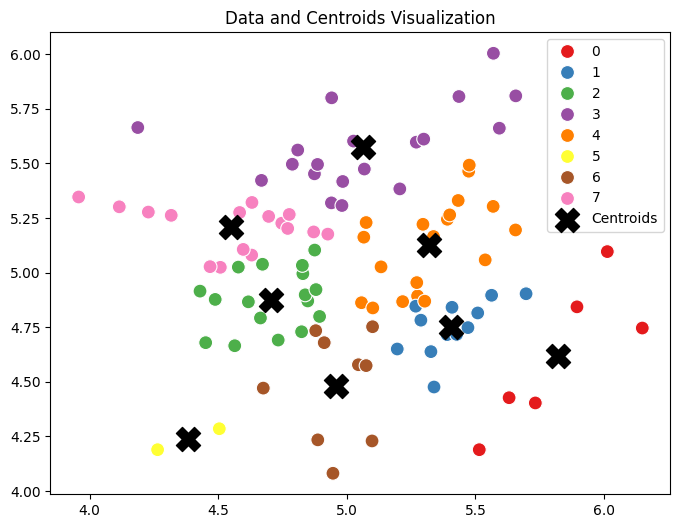

In [41]:
kmeans_restart(data, iters, k, restarts)
# kmeans_restart(udata, iters, restarts)
plot_data_and_centroids("normal.txt", "centroids.txt", "labels.txt")
# plot_data_and_centroids("unbalance.txt", "centroids.txt", "labels.txt")

# centroids, labels = kmeans_plus_plus(udata, k, iters)
# np.savetxt('centroids.txt', centroids, delimiter=' ', fmt='%f')
# np.savetxt('labels.txt', labels, delimiter=' ', fmt='%f')
# # plot_data_and_centroids("normal.txt", "centroids.txt", "labels.txt")
# plot_data_and_centroids("unbalance.txt", "centroids.txt", "labels.txt")